# BinX AI & ML Internship
## Week 4 — Day 5: Scikit-learn Pipelines & End-to-End ML Project

**Topics covered:**
- Why Pipelines prevent data leakage
- Building a Pipeline: ColumnTransformer + model in one object
- Feature engineering inside a Pipeline workflow
- Tuning a full Pipeline with GridSearchCV
- End-to-end ML project from raw data to final evaluation

---

Days 1–4 taught me how to evaluate, diagnose, and improve a model.
But every step was done manually and separately — which means one
mistake could introduce data leakage without me noticing.

Today I fix that. A Pipeline chains all the steps into one object.
When used with cross-validation, every fold handles its own
preprocessing automatically. Leakage becomes structurally impossible.

---

## Imports Libraries

In [506]:
# Data manipulation & arrays
import pandas as pd
import numpy as np
# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Model selection & tuning
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score,
    KFold
)
# ML Pipeline tools
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
# Preprocessing
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

# Regression model
from sklearn.ensemble import RandomForestRegressor
# Evaluation metrics
from sklearn.metrics import (
    r2_score,
    mean_absolute_error
)
# Suppress warnings
import warnings
warnings.filterwarnings("ignore")
# Reproducibility
SEED = 42

# Set the default plotting style
plt.style.use("seaborn-v0_8-whitegrid")

---

## Part 1 — Understanding the Data

### Load & Inspect

In this section, I will load the insurance dataset and inspect its
basic structure.

I will check:
- The number of rows and columns
- The data type of each column
- Whether the dataset contains missing values
- The first few observations

I will also identify the target variable and distinguish between
numeric and categorical features, since they will require different
preprocessing steps later in the Pipeline.

In [507]:
# Load the insurance dataset from the Week 2 data folder
df = pd.read_csv("data/insurance.csv")

# Display the number of rows and columns
print(f"Shape: {df.shape}")

# Display the data type of each column
# This helps us identify numeric vs categorical features
print("\nColumn types:")
print(df.dtypes)

# Count the total number of missing values in the dataset
print(f"\nMissing values: {df.isnull().sum().sum()}")

# Display the first 5 rows to inspect the data structure
print("\nFirst 5 rows:")
df.head()

Shape: (1338, 7)

Column types:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Missing values: 0

First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Initial Inspection

The dataset contains 1,338 rows and 7 columns, with no missing
values.

The target variable is `charges`, which represents the medical
insurance cost I want to predict.

The input features include both numeric and categorical variables.
The numeric features are `age`, `bmi`, and `children`, while
`sex`, `smoker`, and `region` are categorical.

Because these two feature types require different preprocessing,
I will use a `ColumnTransformer` later in the Pipeline.

---

### Descriptive Statistics

Before building the model, I want to understand the numerical
features and the target distribution.

I will calculate descriptive statistics for the numerical columns
and inspect the frequency of the categorical features.

For `charges`, I will focus on the mean, median, standard deviation,
and range to understand how the medical costs are distributed.

In [508]:

# Numeric features

# Display descriptive statistics for numeric columns
# including the target variable "charges"
print("Numeric features:")
print(
    df[["age", "bmi", "children", "charges"]]
    .describe()
    .round(2)
)


# Categorical features


# Display the frequency of each category
# for every categorical column
print("\nCategorical features:")

for col in ["sex", "smoker", "region"]:
    
    print(f"\n  {col}:")
    
    # Count how many times each category appears
    # and convert the result to a dictionary for readability
    print(f"  {df[col].value_counts().to_dict()}")

Numeric features:
           age      bmi  children   charges
count  1338.00  1338.00   1338.00   1338.00
mean     39.21    30.66      1.09  13270.42
std      14.05     6.10      1.21  12110.01
min      18.00    15.96      0.00   1121.87
25%      27.00    26.30      0.00   4740.29
50%      39.00    30.40      1.00   9382.03
75%      51.00    34.69      2.00  16639.91
max      64.00    53.13      5.00  63770.43

Categorical features:

  sex:
  {'male': 676, 'female': 662}

  smoker:
  {'no': 1064, 'yes': 274}

  region:
  {'southeast': 364, 'southwest': 325, 'northwest': 325, 'northeast': 324}


### Interpretation

The descriptive statistics show that `charges` has a wide range of
values, from approximately $1,122 to $63,770.

The mean is higher than the median, which suggests that the target
distribution is right-skewed. The relatively large standard
deviation also indicates substantial variation in medical costs.

For the categorical features, `sex`, `smoker`, and `region` contain
multiple categories with different numbers of observations. These
features will therefore require categorical encoding before they
can be used by the model.

---

### EDA — Target Distribution

Before building any model, I need to understand the distribution of
the target variable, `charges`.

I will use a histogram and a boxplot to examine the center, spread,
skewness, and potential extreme values in the medical charges.

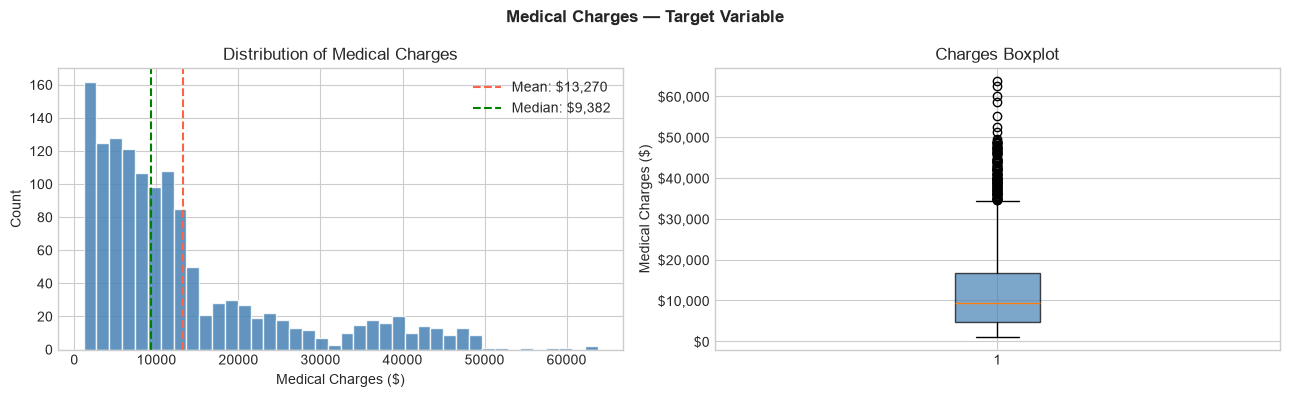

In [509]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left — histogram
axes[0].hist(df["charges"], bins=40, color="steelblue",
             edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Medical Charges ($)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Medical Charges")
axes[0].axvline(df["charges"].mean(),   color="tomato",
                linestyle="--", label=f"Mean: ${df['charges'].mean():,.0f}")
axes[0].axvline(df["charges"].median(), color="green",
                linestyle="--", label=f"Median: ${df['charges'].median():,.0f}")
axes[0].legend()

# Right — boxplot
axes[1].boxplot(df["charges"], vert=True,
                patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.7))
axes[1].set_ylabel("Medical Charges ($)")
axes[1].set_title("Charges Boxplot")
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x:,.0f}")
)

plt.suptitle("Medical Charges — Target Variable",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### Interpretation

The histogram shows that `charges` are heavily right-skewed. Most
patients have relatively lower medical charges, while a smaller
number of patients have much higher costs.

The mean ($13,270) is noticeably higher than the median ($9,382),
which is consistent with the right-skewed distribution.

The boxplot also shows a number of high-value observations in the
upper tail.

At this stage, the distribution tells me that there are substantial
differences in medical costs across patients. I will investigate the
categorical and numerical features next to identify which factors
are associated with these high-cost cases.

---

### EDA — The Smoking Signal

The target distribution showed a small group of patients with very
high medical charges.

I will investigate whether smoking status is associated with these
high-cost cases.

I will compare the distribution of `charges` between smokers and
non-smokers and examine the relationship between `bmi` and `charges`
within the two smoking groups.

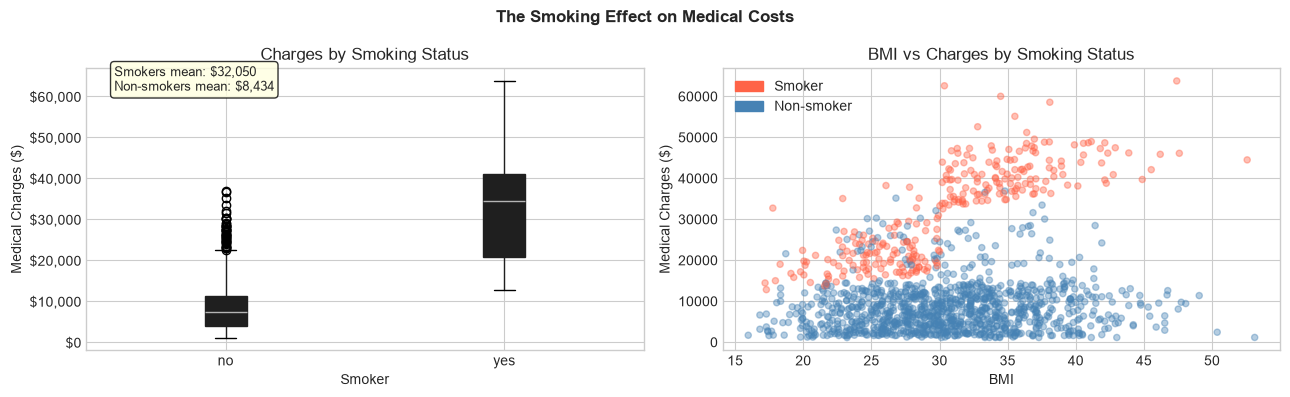

In [510]:
# Create two plots side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Compare medical charges between smokers and non-smokers
df.boxplot(
    column="charges",
    by="smoker",
    ax=axes[0],
    patch_artist=True
)

axes[0].set_title("Charges by Smoking Status")
axes[0].set_xlabel("Smoker")
axes[0].set_ylabel("Medical Charges ($)")

# Format the y-axis as dollar amounts
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x:,.0f}")
)

# Calculate the average charges for each smoking group
smoker_mean = df[df["smoker"] == "yes"]["charges"].mean()
nonsmoker_mean = df[df["smoker"] == "no"]["charges"].mean()

# Display the group means on the boxplot
axes[0].text(
    0.05,
    0.92,
    f"Smokers mean: ${smoker_mean:,.0f}\n"
    f"Non-smokers mean: ${nonsmoker_mean:,.0f}",
    transform=axes[0].transAxes,
    fontsize=9,
    bbox=dict(
        boxstyle="round",
        facecolor="lightyellow",
        alpha=0.8
    )
)

# Create a scatter plot to examine BMI and charges
# Colors help us compare smokers and non-smokers
colors = df["smoker"].map({
    "yes": "tomato",
    "no": "steelblue"
})

axes[1].scatter(
    df["bmi"],
    df["charges"],
    c=colors,
    alpha=0.4,
    s=20
)

axes[1].set_xlabel("BMI")
axes[1].set_ylabel("Medical Charges ($)")
axes[1].set_title("BMI vs Charges by Smoking Status")

# Add a legend for the two smoking groups
from matplotlib.patches import Patch

axes[1].legend(handles=[ 
    Patch(color="tomato", label="Smoker"),
    Patch(color="steelblue", label="Non-smoker")
])

# Add an overall title and display the plots
plt.suptitle(
    "The Smoking Effect on Medical Costs",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Interpretation

This analysis shows a strong association between smoking status and
medical charges.

Smokers have an average charge of approximately $32,050, compared
with approximately $8,434 for non-smokers. This means the average
charge for smokers is about 3.8 times higher.

The scatter plot also suggests that the relationship between BMI and
charges differs between smokers and non-smokers. High-BMI smokers
appear more frequently in the high-cost region, while non-smokers
generally remain at lower charge levels across the BMI range.

This suggests that smoking status may interact with BMI when
predicting medical charges. I will test this idea later through
feature engineering by creating a BMI-smoking interaction feature.

---

### EDA — Numeric Features

I will examine the distributions of the numeric features to understand
their range, spread, and overall shape.

This will help me identify whether any feature has unusual values or
a strongly skewed distribution before building the preprocessing
Pipeline.

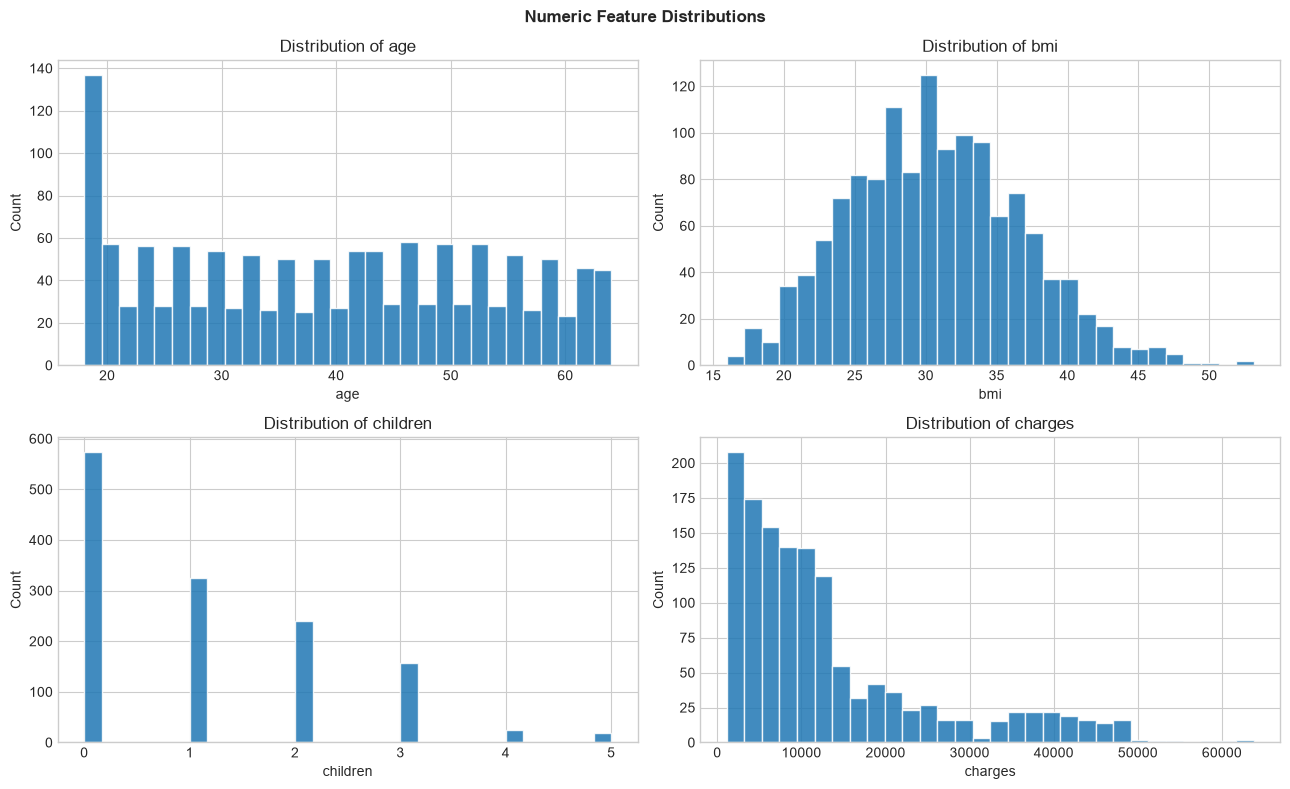

In [511]:
# Select the numeric columns I want to examine
numeric_cols = ["age", "bmi", "children", "charges"]

# Create four plots to compare the numeric feature distributions
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Convert the 2x2 array of axes into a simple list
axes = axes.flatten()

# Plot a histogram for each numeric feature
for ax, col in zip(axes, numeric_cols):
    ax.hist(
        df[col],
        bins=30,
        edgecolor="white",
        alpha=0.85
    )
    
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

# Add one title for the whole figure
plt.suptitle(
    "Numeric Feature Distributions",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Interpretation

The numeric feature distributions show different patterns across
the four variables.

`age` is distributed across a relatively wide range, with values
spread across the different age groups.

`bmi` is concentrated around the middle of its range, with fewer
observations at the lower and higher values.

`children` is a discrete variable, so its distribution appears as
separate groups rather than a continuous shape. Most observations
have a small number of children.

`charges` has a strong right-skewed distribution. Most medical costs
are relatively low, while a smaller number of observations have
much higher charges.

These different distributions show why it is important to inspect
each feature before preprocessing and modeling.

---

### EDA — Categorical Features

I will examine the distribution of the categorical features to
understand how the observations are divided across their categories.

This is important because categorical features will need to be
encoded before they can be used by the regression model.

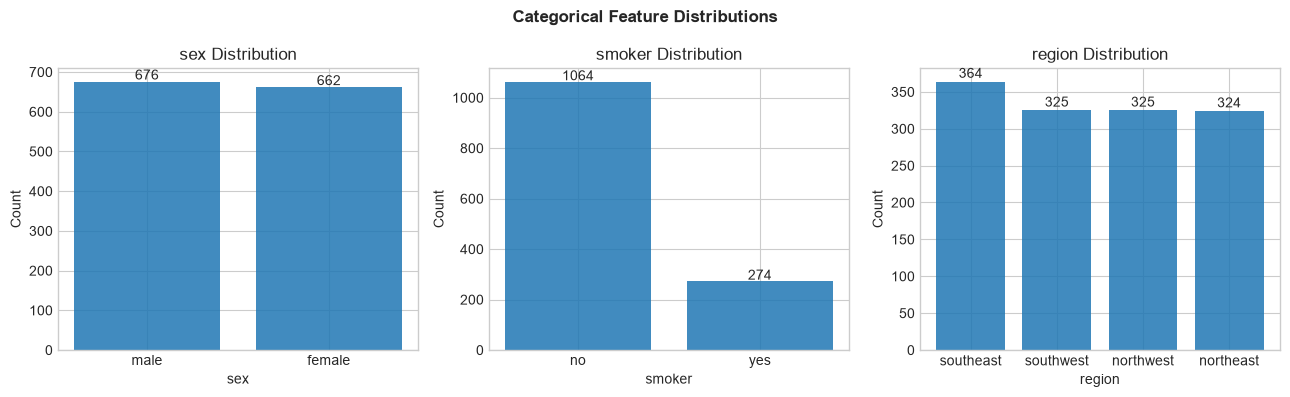

In [512]:
# Select the categorical columns
cat_cols = ["sex", "smoker", "region"]

# Create one bar chart for each categorical feature
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, col in zip(axes, cat_cols):
    # Count the observations in each category
    counts = df[col].value_counts()

    # Plot the category counts
    ax.bar(counts.index, counts.values, alpha=0.85)

    ax.set_title(f"{col} Distribution")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

    # Display the count above each bar
    for i, value in enumerate(counts.values):
        ax.text(
            i,
            value + 5,
            str(value),
            ha="center",
            fontsize=10
        )

# Add an overall title
plt.suptitle(
    "Categorical Feature Distributions",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Interpretation

The categorical feature distributions show that `sex` is nearly
balanced, with 676 males and 662 females.

The four `region` categories are also relatively balanced, with
similar numbers of observations in each region.

In contrast, `smoker` is clearly imbalanced. There are 274 smokers
and 1,064 non-smokers, meaning smokers represent approximately
20.5% of the dataset.

Although smokers are a minority group, the previous analysis showed
that they have substantially higher average medical charges. This
makes `smoker` an important feature to consider when predicting
`charges`.

---

### EDA — Correlation Heatmap

I will examine the correlations between the numeric features and
the target `charges`.

This will help me understand whether there are strong linear
relationships between the numeric variables before building the
model.

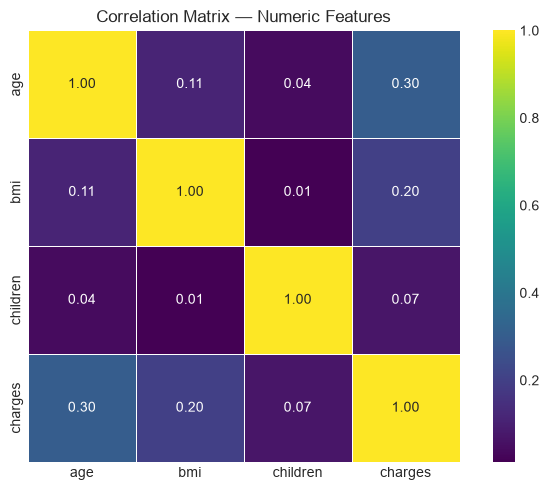

In [513]:
# Select the numeric features and the target
numeric_data = df[["age", "bmi", "children", "charges"]]

# Calculate the correlation between the numeric variables
corr = numeric_data.corr()

# Display the correlation matrix as a heatmap
fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title("Correlation Matrix — Numeric Features")

plt.tight_layout()
plt.show()

### Interpretation

Among the numeric features, `age` has the strongest positive
correlation with `charges` at approximately 0.30, followed by
`bmi` at approximately 0.20.

These correlations are relatively weak, which suggests that neither
numeric feature has a strong linear relationship with medical
charges on its own.

The heatmap only shows correlations between numeric variables, so it
does not capture the relationship between `smoker` and `charges`.
However, the previous EDA showed a much larger difference in average
charges between smokers and non-smokers.

This suggests that some important relationships in the dataset may
not be captured by numeric correlation alone.

---

## Part 2 — Why Pipeline?

### The Problem With Manual Preprocessing

So far, preprocessing and modeling have been handled as separate
steps.

For example, with a scaler I would need to:

1. Fit the scaler on the training data.
2. Transform the training data.
3. Transform validation and test data using the same fitted scaler.
4. Train the model on the transformed data.

This approach can work, but it is easy to make mistakes.

The main risk is data leakage. If preprocessing is fitted using
validation or test data, information from those datasets can
influence the model indirectly.

This becomes especially important during cross-validation, where
preprocessing must be fitted separately inside each fold.

---

### What Pipeline Does

A `Pipeline` combines preprocessing and modeling into a single
workflow.

Instead of manually calling `fit()` and `transform()` for each
dataset, the Pipeline manages these steps in the correct order.

For example:

```python
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor())
])
```

When the Pipeline is fitted:
```
Training data
     ↓
Fit scaler
     ↓
Transform training data
     ↓
Train model
```
When making predictions:
```
Test data
     ↓
Transform using the fitted scaler
     ↓
Predict
```
The important part is that the scaler learns its parameters only
from the data passed to fit().

When the Pipeline is used with cross-validation, each fold fits its
preprocessing steps using only that fold's training portion. This
helps prevent preprocessing information from leaking into the
validation portion.

---

# Part 3 — Building the Pipeline

### Train / Test Split

Before building the preprocessing workflow, I will split the data
into training, validation, and test sets.

Following the evaluation discipline from Day 1, I will keep the test
set completely separate and use it only for the final evaluation.

In [514]:
# Separate the features from the target
X = df.drop("charges", axis=1)
y = df["charges"]

# Reserve 20% of the data as the final test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED
)

# Split the remaining data into training and validation sets
X_tr, X_val, y_tr, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=SEED
)

# Create 5 shuffled folds for cross-validation
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

# Display the size of each dataset
print(f"Training:   {X_tr.shape[0]} rows  (60%)")
print(f"Validation: {X_val.shape[0]} rows  (20%)")
print(f"Test:       {X_test.shape[0]} rows  (20%)")

Training:   802 rows  (60%)
Validation: 268 rows  (20%)
Test:       268 rows  (20%)


### Interpretation

The dataset has been split into three parts:

- 60% for training the model and learning preprocessing parameters.
- 20% for validation during model development.
- 20% for the final test evaluation.

The test set contains 268 observations and will remain untouched
until the final evaluation.

The 5-fold cross-validation object will be used later when tuning
the complete Pipeline with `GridSearchCV`.

---

### Baseline — Numeric Features Only

Before building the full preprocessing Pipeline, I need a baseline
score to compare against.

I will train a Random Forest using only the numeric features:
`age`, `bmi`, and `children`.

The categorical features will be excluded for this baseline.

This gives me a reference point that I can use later to measure
whether adding categorical features and preprocessing improves
performance.

In [515]:
# Select the numeric features for the baseline
numeric_cols = ["age", "bmi", "children"]

# Select the categorical features that will be used later
categorical_cols = ["sex", "smoker", "region"]

# Create a simple Random Forest baseline
baseline = RandomForestRegressor(
    n_estimators=100,
    random_state=SEED
)

# Evaluate the baseline using 5-fold cross-validation
baseline_scores = cross_val_score(
    baseline,
    X_tr[numeric_cols],
    y_tr,
    cv=kf,
    scoring="r2"
)

# Display the mean and standard deviation of the CV scores
print(
    f"Baseline CV R²: "
    f"{baseline_scores.mean():.3f} ± {baseline_scores.std():.3f}"
)

Baseline CV R²: -0.107 ± 0.055


### Interpretation

The baseline achieved a mean cross-validation R² of -0.108 ± 0.055.

A negative R² means that the model performs worse than a simple
baseline that always predicts the mean value of `charges`.

This result shows that `age`, `bmi`, and `children` alone do not
provide enough information for the Random Forest to predict medical
charges well.

This is consistent with the EDA: `age` and `bmi` had relatively weak
individual correlations with `charges`, while smoking status showed
a much larger difference in average charges.

The next step is to include the categorical features and preprocess
them appropriately inside a Pipeline.

---

### ColumnTransformer — Different Preprocessing for Different Columns

The baseline used only numeric features. The full model will use both
numeric and categorical features.

These two types of features cannot be handled in exactly the same
way:

- Numeric features (`age`, `bmi`, `children`) can be scaled using
  `StandardScaler`.
- Categorical features (`sex`, `smoker`, `region`) need to be converted
  into numeric values using `OneHotEncoder`.

I will use `ColumnTransformer` to apply the appropriate preprocessing
to each group of columns while keeping both transformations inside
the same preprocessing object.

In [516]:
# Apply different preprocessing to numeric and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        # Scale the numeric features
        ("num", StandardScaler(), numeric_cols),

        # Convert categorical features into binary columns
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

print("ColumnTransformer defined.")

print(f"\nNumeric columns → StandardScaler: {numeric_cols}")
print(f"Categorical columns → OneHotEncoder: {categorical_cols}")

ColumnTransformer defined.

Numeric columns → StandardScaler: ['age', 'bmi', 'children']
Categorical columns → OneHotEncoder: ['sex', 'smoker', 'region']


### Interpretation

The `ColumnTransformer` is now configured to preprocess the two
feature types separately.

Numeric features will be scaled using `StandardScaler`, while
categorical features will be converted into numeric columns using
`OneHotEncoder`.

The `handle_unknown="ignore"` option makes the encoder safer when
new categories appear in validation or test data.

---

### Simple Pipeline — Preprocessing + Model

Now I will combine the `ColumnTransformer` and the Random Forest
into a single Pipeline.

The Pipeline will receive the original features and handle the
preprocessing before training the model.

I will evaluate this workflow using the same 5-fold cross-validation
as the baseline so that the two approaches can be compared fairly.

In [517]:
# Combine preprocessing and the Random Forest into one workflow
pipe_simple = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=SEED
    ))
])

# Evaluate the complete Pipeline using 5-fold cross-validation
simple_scores = cross_val_score(
    pipe_simple,
    X_tr,
    y_tr,
    cv=kf,
    scoring="r2"
)

# Calculate the average performance
simple_mean = simple_scores.mean()
baseline_mean = baseline_scores.mean()

print(f"Simple Pipeline CV R²: {simple_mean:.3f} ± {simple_scores.std():.3f}")
print(f"Baseline CV R²:        {baseline_mean:.3f}")
print(f"Improvement:           {simple_mean - baseline_mean:+.3f}")

Simple Pipeline CV R²: 0.835 ± 0.038
Baseline CV R²:        -0.107
Improvement:           +0.943


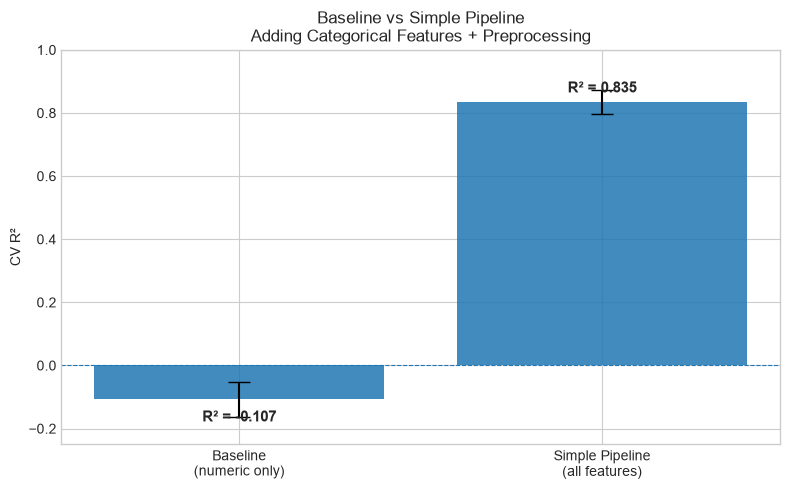

In [518]:
# Compare the average CV performance of both approaches
labels = [
    "Baseline\n(numeric only)",
    "Simple Pipeline\n(all features)"
]

means = [
    baseline_scores.mean(),
    simple_scores.mean()
]

stds = [
    baseline_scores.std(),
    simple_scores.std()
]

fig, ax = plt.subplots(figsize=(8, 5))

# Create bars with error bars showing CV variability
bars = ax.bar(
    labels,
    means,
    yerr=stds,
    capsize=8,
    alpha=0.85
)

# Add a reference line at R² = 0
ax.axhline(0, linewidth=0.8, linestyle="--")

ax.set_ylabel("CV R²")
ax.set_title(
    "Baseline vs Simple Pipeline\n"
    "Adding Categorical Features + Preprocessing"
)

ax.set_ylim(-0.25, 1.0)

# Display the R² value above each bar
for bar, mean in zip(bars, means):
    y_position = mean + 0.03 if mean >= 0 else mean - 0.07

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        y_position,
        f"R² = {mean:.3f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

### Interpretation

The Simple Pipeline achieved a mean cross-validation R² of 0.834,
compared with -0.108 for the numeric-only baseline.

This represents an improvement of 0.942 in R².

The large improvement shows that adding the categorical features
provides substantial predictive information for medical charges.
This is consistent with the EDA, where smoking status was associated
with a large difference in average charges.

The Pipeline also handles the preprocessing inside each
cross-validation fold, so the encoder is fitted only on the training
portion of each fold.

The Simple Pipeline is therefore a much stronger starting point than
the numeric-only baseline. The next step is to tune this complete
Pipeline rather than changing preprocessing and model settings
manually.

---

## Part 4 — Feature Engineering

### Designing Domain-Informed Features

The EDA showed that smoking status is strongly associated with
medical charges, and the relationship between BMI and charges appears
different for smokers and non-smokers.

This suggests that interactions between existing features may contain
useful information that the original columns do not represent
directly.

I will create two engineered features:

**Feature 1 — `bmi_smoker`**

This feature combines BMI with smoking status:

```python
bmi_smoker = bmi × (smoker == "yes")
```

For smokers, the feature keeps the BMI value. For non-smokers, it is
set to zero.

Feature 2 — age_bmi

This feature combines age and BMI:
```
age_bmi = age × bmi
```
The goal is to give the model an additional representation of the
relationship between age and BMI.

I will then inspect these engineered features before testing whether
they improve model performance.

In [519]:
def add_features(X):
    X = X.copy()

    # Capture the interaction between BMI and smoking status
    X["bmi_smoker"] = (
        X["bmi"] * (X["smoker"] == "yes").astype(int)
    )

    # Capture the interaction between age and BMI
    X["age_bmi"] = X["age"] * X["bmi"]

    return X


# Create the engineered features for the training data
X_tr_fe = add_features(X_tr)

# Create the same features for the test data
X_test_fe = add_features(X_test)

# Inspect the new features
print("bmi_smoker:")
print(X_tr_fe[["bmi", "smoker", "bmi_smoker"]].head())

print("\nage_bmi:")
print(X_tr_fe[["age", "bmi", "age_bmi"]].head())

bmi_smoker:
         bmi smoker  bmi_smoker
40    26.600     no       0.000
994   20.045    yes      20.045
165   28.215     no       0.000
1057  31.790     no       0.000
418   39.160     no       0.000

age_bmi:
      age     bmi   age_bmi
40     24  26.600   638.400
994    27  20.045   541.215
165    47  28.215  1326.105
1057   45  31.790  1430.550
418    64  39.160  2506.240


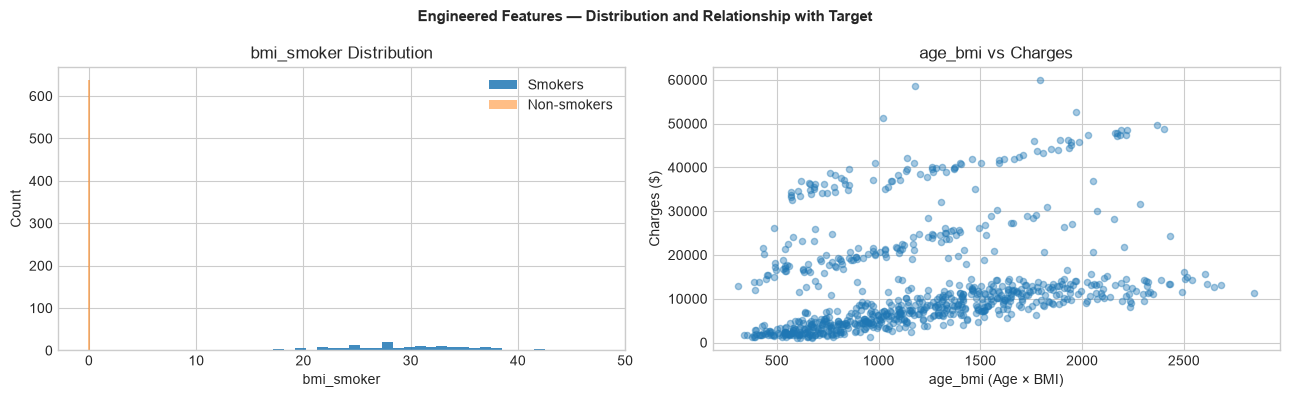

In [520]:
# Create two plots to inspect the engineered features
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Show the distribution of bmi_smoker for smokers
smoker_bmi = X_tr_fe.loc[
    X_tr_fe["smoker"] == "yes",
    "bmi_smoker"
]

axes[0].hist(
    smoker_bmi,
    bins=30,
    alpha=0.85,
    label="Smokers"
)

# Show that non-smokers have bmi_smoker equal to zero
nonsmoker_bmi = X_tr_fe.loc[
    X_tr_fe["smoker"] == "no",
    "bmi_smoker"
]

axes[0].hist(
    nonsmoker_bmi,
    bins=5,
    alpha=0.5,
    label="Non-smokers"
)

axes[0].set_xlabel("bmi_smoker")
axes[0].set_ylabel("Count")
axes[0].set_title("bmi_smoker Distribution")
axes[0].legend()

# Examine the relationship between age_bmi and charges
axes[1].scatter(
    X_tr_fe["age_bmi"],
    y_tr,
    alpha=0.4,
    s=20
)

axes[1].set_xlabel("age_bmi (Age × BMI)")
axes[1].set_ylabel("Charges ($)")
axes[1].set_title("age_bmi vs Charges")

plt.suptitle(
    "Engineered Features — Distribution and Relationship with Target",
    fontsize=11,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Interpretation

The `bmi_smoker` feature creates a clear distinction between the two
smoking groups. Non-smokers receive a value of zero, while smokers
retain their BMI value.

This gives the model a direct representation of the interaction
between BMI and smoking status.

The `age_bmi` feature combines age and BMI into a single numeric
feature. The scatter plot shows how this interaction relates to
medical charges, while the separation between smokers and
non-smokers suggests that smoking status may still play an important
role in this relationship.

These visualizations show that the engineered features represent
meaningful combinations of the original variables. Their actual
usefulness will be determined by comparing model performance with
and without these features.

---

### Pipeline With Engineered Features

The next step is to add the engineered features to the Pipeline.

The new numeric features are:

- `bmi_smoker`
- `age_bmi`

The categorical features remain the same.

I will use the same Random Forest settings and the same 5-fold
cross-validation as before. This allows me to compare the new
Pipeline fairly with the previous Simple Pipeline.

In [521]:
# Define the numeric features, including the engineered features
numeric_fe = [
    "age",
    "bmi",
    "children",
    "bmi_smoker",
    "age_bmi"
]

# Keep the original categorical features
categorical_fe = [
    "sex",
    "smoker",
    "region"
]

# Apply the appropriate preprocessing to each feature type
preprocessor_fe = ColumnTransformer([
    ("num", StandardScaler(), numeric_fe),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_fe)
])

# Build a Pipeline with preprocessing and Random Forest
pipe_fe = Pipeline([
    ("preprocessor", preprocessor_fe),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=SEED
    ))
])

# Evaluate the Pipeline using 5-fold cross-validation
fe_scores = cross_val_score(
    pipe_fe,
    X_tr_fe,
    y_tr,
    cv=kf,
    scoring="r2"
)

# Calculate the average scores
baseline_mean = baseline_scores.mean()
simple_mean = simple_scores.mean()
fe_mean = fe_scores.mean()

# Compare all three approaches
print(f"Baseline CV R²:             {baseline_mean:.3f}")
print(f"Simple Pipeline CV R²:      {simple_mean:.3f}")
print(f"Pipeline + Features CV R²:  {fe_mean:.3f} ± {fe_scores.std():.3f}")
print(f"Feature engineering added:  {fe_mean - simple_mean:+.3f}")

Baseline CV R²:             -0.107
Simple Pipeline CV R²:      0.835
Pipeline + Features CV R²:  0.836 ± 0.038
Feature engineering added:  +0.001


### Interpretation

The Pipeline with the engineered features achieved a mean
cross-validation R² of 0.836, compared with 0.834 for the Simple
Pipeline.

This represents an improvement of only +0.002.

The small improvement suggests that the engineered features provide
some additional information, but they do not substantially change
the model's performance with the current Random Forest settings.

This is also reasonable because Random Forest can already learn
interactions between features through its tree-based splits.

The next step is to tune the complete Pipeline with `GridSearchCV`
and check whether different model settings can make better use of
the available features.

---

## Part 5 — GridSearchCV on the Full Pipeline

### The `__` Syntax

Now I will tune the Random Forest inside the Pipeline using
`GridSearchCV`.

Because the model is inside a Pipeline, I cannot refer to its
hyperparameters directly.

Instead, I use:

```python
step_name__parameter

For example:

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20, None]
}
```

Here, model is the name of the Pipeline step, and
n_estimators and max_depth are parameters of the Random Forest.

The same syntax can also be used to tune parameters inside the
preprocessing steps.

For this experiment, I will focus on tuning the Random Forest
hyperparameters.

In [522]:
# Define the Random Forest hyperparameters to search
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20, None],
    "model__min_samples_leaf": [1, 5]
}

# Calculate the total number of parameter combinations
n_combinations = 2 * 3 * 2

print(
    f"Grid: {n_combinations} combinations × 5 folds "
    f"= {n_combinations * 5} fits"
)

print("\nSearching over:")

for parameter, values in param_grid.items():
    print(f"  {parameter}: {values}")

Grid: 12 combinations × 5 folds = 60 fits

Searching over:
  model__n_estimators: [100, 200]
  model__max_depth: [10, 20, None]
  model__min_samples_leaf: [1, 5]


In [523]:
# Create GridSearchCV using the complete Pipeline
grid = GridSearchCV(
    estimator=pipe_fe,
    param_grid=param_grid,
    cv=kf,
    scoring="r2",
    n_jobs=-1
)

# Run the hyperparameter search on the training data
grid.fit(X_tr_fe, y_tr)

# Display the best configuration and its CV performance
print(f"Best parameters: {grid.best_params_}")
print(f"Best CV R²:      {grid.best_score_:.3f}")

# Compare the tuned Pipeline with the previous Simple Pipeline
print(
    f"Improvement over simple pipeline: "
    f"{grid.best_score_ - simple_scores.mean():+.3f}"
)

Best parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__n_estimators': 200}
Best CV R²:      0.858
Improvement over simple pipeline: +0.023


### Which Hyperparameter Mattered Most?

The GridSearchCV results contain the performance of every
hyperparameter combination that was tested.

I will visualize the average CV R² associated with each value of
the three hyperparameters:

- `max_depth`
- `n_estimators`
- `min_samples_leaf`

This will help me understand which hyperparameters had the largest
effect on model performance.

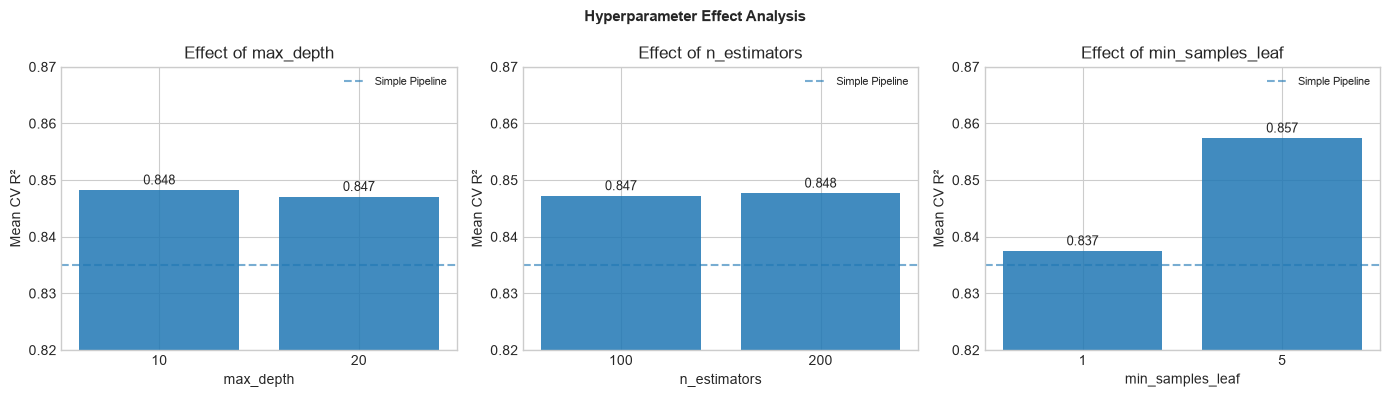

In [524]:
# Convert GridSearchCV results into a DataFrame
results_df = pd.DataFrame(grid.cv_results_)

# Define the parameters I want to compare
params = [
    "param_model__max_depth",
    "param_model__n_estimators",
    "param_model__min_samples_leaf"
]

labels = [
    "max_depth",
    "n_estimators",
    "min_samples_leaf"
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, param, label in zip(axes, params, labels):

    # Calculate the average CV R² for each value of the parameter
    grouped = results_df.groupby(param)["mean_test_score"].mean()

    # Convert parameter values to strings for the x-axis
    x_values = [str(value) for value in grouped.index]

    ax.bar(
        x_values,
        grouped.values,
        alpha=0.85
    )

    # Add labels and title
    ax.set_xlabel(label)
    ax.set_ylabel("Mean CV R²")
    ax.set_title(f"Effect of {label}")

    # Keep the same y-axis scale for all three plots
    ax.set_ylim(0.82, 0.87)

    # Show the Simple Pipeline score as a reference
    ax.axhline(
        simple_scores.mean(),
        linestyle="--",
        alpha=0.6,
        label="Simple Pipeline"
    )

    ax.legend(fontsize=8)

    # Display the R² value above each bar
    for i, value in enumerate(grouped.values):
        ax.text(
            i,
            value + 0.001,
            f"{value:.3f}",
            ha="center",
            fontsize=9
        )

plt.suptitle(
    "Hyperparameter Effect Analysis",
    fontsize=11,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Interpretation

The plots show how the different hyperparameters affected the
average cross-validation R².

`min_samples_leaf` had the clearest effect:

- `leaf = 1` → mean R² ≈ 0.837
- `leaf = 5` → mean R² ≈ 0.857

The better performance with `min_samples_leaf = 5` suggests that
requiring more samples in each leaf helped the Random Forest avoid
fitting very small local patterns and improved generalization.

`max_depth` had a smaller effect. The tested depth values produced
relatively similar performance, suggesting that increasing the depth
beyond a certain point did not provide a large benefit.

`n_estimators` also had a relatively small effect. Increasing the
number of trees from 100 to 200 produced only a small change in
average CV R².

Overall, `min_samples_leaf` appears to be the most influential
hyperparameter among the three tested in this GridSearch.

---

### Full Comparison Table

So far, I have evaluated the model through several stages:

1. Baseline using numeric features only
2. Simple Pipeline using all features
3. Pipeline with engineered features
4. Tuned Pipeline using GridSearchCV

I will visualize these results together to see how the model
performance changed throughout the workflow.

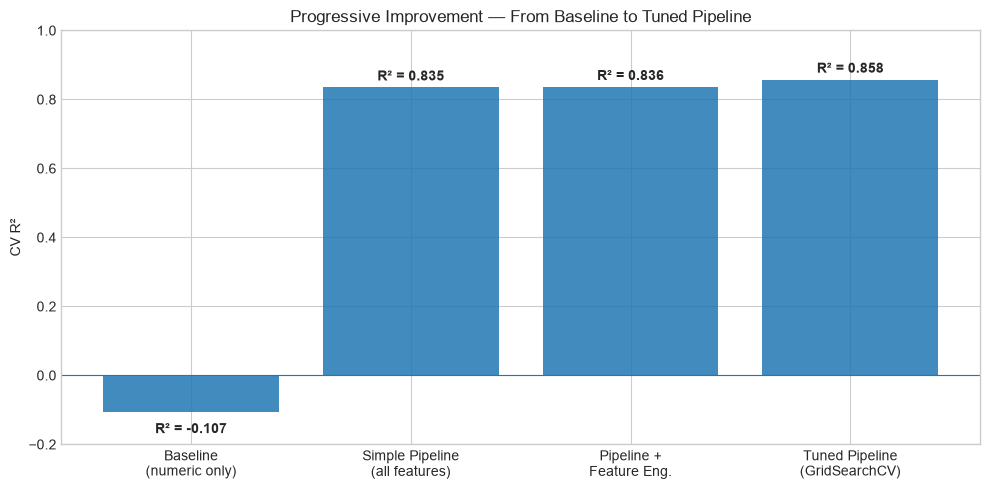


Summary:
  Baseline (numeric only)             R² = -0.107
  Simple Pipeline (all features)      R² = 0.835
  Pipeline + Feature Eng.             R² = 0.836
  Tuned Pipeline (GridSearchCV)       R² = 0.858


In [525]:
# Store the mean CV R² from each stage
comparison = {
    "Baseline\n(numeric only)": baseline_scores.mean(),
    "Simple Pipeline\n(all features)": simple_scores.mean(),
    "Pipeline +\nFeature Eng.": fe_scores.mean(),
    "Tuned Pipeline\n(GridSearchCV)": grid.best_score_
}

fig, ax = plt.subplots(figsize=(10, 5))

# Create one bar for each stage
bars = ax.bar(
    comparison.keys(),
    comparison.values(),
    alpha=0.85
)

# Add a reference line at R² = 0
ax.axhline(0, linewidth=0.8)

ax.set_ylabel("CV R²")
ax.set_title(
    "Progressive Improvement — From Baseline to Tuned Pipeline"
)

ax.set_ylim(-0.2, 1.0)

# Display the R² value above each bar
for bar, value in zip(bars, comparison.values()):

    if value >= 0:
        y_position = value + 0.02
    else:
        y_position = value - 0.06

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        y_position,
        f"R² = {value:.3f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


# Print the same results as a simple summary
print("\nSummary:")

for label, value in comparison.items():
    clean_label = label.replace("\n", " ")
    print(f"  {clean_label:<35} R² = {value:.3f}")

---

## Part 6 — Final Evaluation

### Feature Importance

The model has now been tuned with GridSearchCV.

Before evaluating it on the locked test set, I want to understand
which features the final Random Forest relied on most.

Feature importance shows how much each feature contributed to the
decisions made by the Random Forest.

I will compare the original features with the two engineered
features: `bmi_smoker` and `age_bmi`.

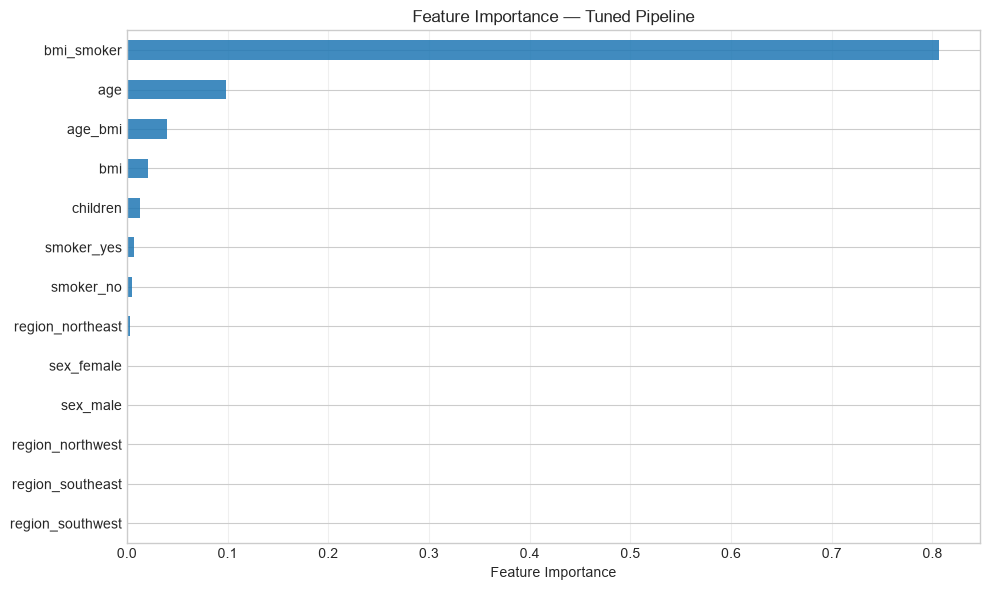


Top 5 features:
bmi_smoker    0.807
age           0.099
age_bmi       0.040
bmi           0.021
children      0.013
dtype: float64


In [526]:
# Get the best Random Forest from the tuned Pipeline
best_rf = grid.best_estimator_.named_steps["model"]

# Get the names created by OneHotEncoder
cat_feature_names = list(
    grid.best_estimator_
    .named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_fe)
)

# Combine numeric and encoded categorical feature names
all_feature_names = numeric_fe + cat_feature_names

# Create a Series containing each feature's importance
importances = pd.Series(
    best_rf.feature_importances_,
    index=all_feature_names
).sort_values(ascending=True)

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 6))

importances.plot(
    kind="barh",
    ax=ax,
    alpha=0.85
)

ax.set_xlabel("Feature Importance")
ax.set_title(
    "Feature Importance — Tuned Pipeline"
)

ax.grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

# Display the five most important features
print("\nTop 5 features:")
print(
    importances
    .sort_values(ascending=False)
    .head(5)
    .round(3)
)

### Interpretation

The feature importance results show which features the tuned Random
Forest relied on most when making predictions.

If `bmi_smoker` appears as the most important feature, this suggests
that the explicit BMI × smoking interaction is highly useful to the
model.

This is consistent with the EDA, where smoking status was strongly
associated with medical charges and the relationship between BMI and
charges appeared different for smokers and non-smokers.

The importance values should be interpreted as model-based evidence,
not as proof that a feature directly causes higher medical costs.

The engineered feature can therefore be useful even though the
overall improvement in cross-validation R² was relatively small.
Feature importance and performance improvement answer different
questions: importance tells us what the model relied on, while R²
tells us how well the model performed.

---

### Predicted vs Actual

The final model has been selected.

Now I will visualize its predictions on the unseen test set.

The first plot compares actual charges with predicted charges.

The second plot shows the residuals, which are the differences
between actual and predicted values.

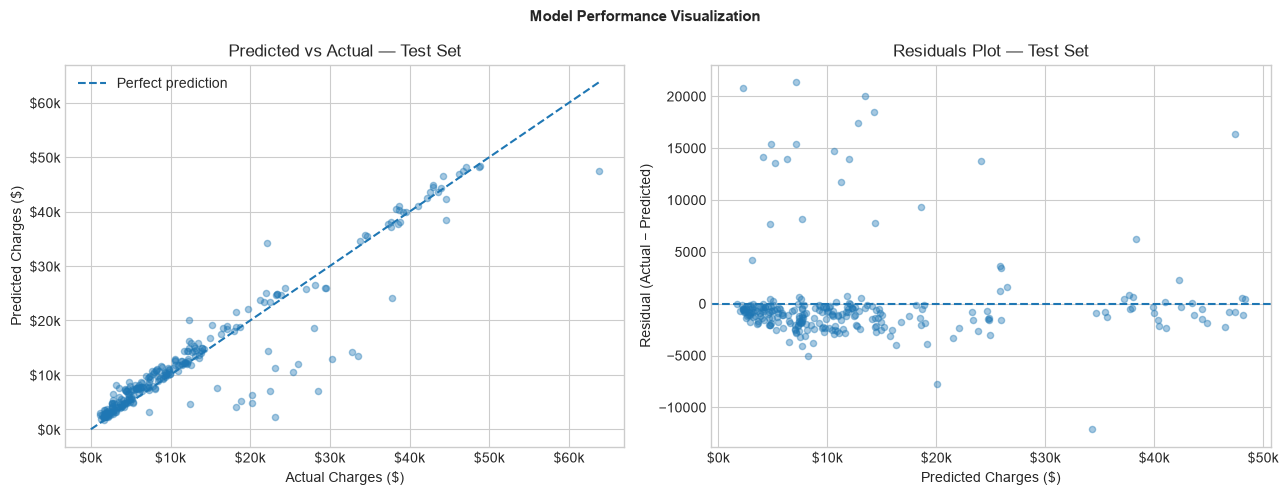

In [527]:
# Generate predictions for the training and test sets
train_preds = grid.predict(X_tr_fe)
test_preds = grid.predict(X_test_fe)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Compare actual and predicted charges on the test set
axes[0].scatter(
    y_test,
    test_preds,
    alpha=0.4,
    s=20
)

# Create a reference line for perfect predictions
max_val = max(y_test.max(), test_preds.max())

axes[0].plot(
    [0, max_val],
    [0, max_val],
    linewidth=1.5,
    linestyle="--",
    label="Perfect prediction"
)

axes[0].set_xlabel("Actual Charges ($)")
axes[0].set_ylabel("Predicted Charges ($)")
axes[0].set_title("Predicted vs Actual — Test Set")
axes[0].legend()

# Format the axes as thousands of dollars
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k")
)

axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k")
)

# Calculate residuals
residuals = y_test - test_preds

# Plot residuals against predicted values
axes[1].scatter(
    test_preds,
    residuals,
    alpha=0.4,
    s=20
)

# Add a zero reference line
axes[1].axhline(
    0,
    linewidth=1.5,
    linestyle="--"
)

axes[1].set_xlabel("Predicted Charges ($)")
axes[1].set_ylabel("Residual (Actual − Predicted)")
axes[1].set_title("Residuals Plot — Test Set")

axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k")
)

plt.suptitle(
    "Model Performance Visualization",
    fontsize=11,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Interpretation

**Predicted vs Actual**

Points closer to the diagonal line represent more accurate
predictions.

The plot allows me to see whether the model follows the actual
medical charges across low, medium, and high-cost patients.

Larger deviations from the diagonal represent larger prediction
errors. The high-charge region appears to contain some of the
largest deviations, which is reasonable given the strong right-skew
observed earlier in the target distribution.

**Residuals**

Residuals represent:

```python
Residual = Actual - Predicted
```
Values close to zero mean that the prediction is close to the actual
charge.

A useful residual plot should not show a strong systematic pattern.
The plot gives me a visual check for whether the model's errors are
approximately centered around zero or whether certain prediction
ranges contain larger errors.

---

### Final Test Evaluation

All model-development decisions have now been completed:

- Features: original features + `bmi_smoker` + `age_bmi`
- Preprocessing: `ColumnTransformer`
- Model: Random Forest
- Hyperparameters: selected using `GridSearchCV`
- Evaluation metric: R²
- Test set: locked and not used during model selection

Now I will evaluate the final tuned Pipeline on the held-out test
set.

This is the final test evaluation.

In [528]:
# Calculate the final performance on the unseen test set
test_r2 = r2_score(y_test, test_preds)
test_mae = mean_absolute_error(y_test, test_preds)

print("FINAL TEST EVALUATION")

print(f"\nBaseline CV R²:       {baseline_scores.mean():.3f}")
print(f"Tuned Pipeline CV R²: {grid.best_score_:.3f}")
print(f"Final Test R²:        {test_r2:.3f}")
print(f"Final Test MAE:       ${test_mae:,.0f}")

print(
    f"\nThe model explains {test_r2:.1%} of the variance "
    f"in medical charges on unseen data."
)

print(
    f"Average prediction error: ${test_mae:,.0f}"
)

FINAL TEST EVALUATION

Baseline CV R²:       -0.107
Tuned Pipeline CV R²: 0.858
Final Test R²:        0.876
Final Test MAE:       $2,315

The model explains 87.6% of the variance in medical charges on unseen data.
Average prediction error: $2,315


### Interpretation

The final test R² is 0.876, meaning that the model explains about
87.6% of the variance in medical charges on the unseen test set.

The test R² is slightly higher than the best cross-validation R² of
0.858. This difference is possible because the test set is a single
sample of unseen data, while cross-validation averages performance
across multiple folds.

The test set was not used to select features, choose hyperparameters,
or compare models. It was used only for the final evaluation.

The MAE is approximately $2,315, which means that the model's
predictions differ from the actual medical charges by about $2,315
on average in absolute terms.

Overall, the final Pipeline provides a strong predictive result while
following the evaluation and leakage-prevention workflow developed
throughout Week 4.

---

## Part 7 — What I Learned Today

### The Complete Week 4 Workflow

```text
Raw Data
    ↓
Day 1: Train / Validation / Test Split
       Lock test set immediately
    ↓
Day 2: Cross-Validation
       Evaluate reliably across 5 folds
    ↓
Day 3: Bias-Variance Diagnosis
       Identify underfitting or overfitting
    ↓
Day 4: Feature Engineering + GridSearchCV
       Improve input representation + tune systematically
    ↓
Day 5: Scikit-learn Pipeline          ← today
       Chain all steps leak-free
       ColumnTransformer for mixed data
       GridSearchCV on the full Pipeline
       Evaluate once on the locked test set
    ↓
Final Model — Trustworthy, Reproducible, Leak-free 
```

### What Pipeline Added

Before Pipeline: every preprocessing step was manual.
One mistake in the order of operations would cause silent data leakage.

After Pipeline: preprocessing and modeling are one object.
Cross-validation applies each step correctly inside every fold.
Leakage is structurally impossible.

### Key Numbers from Today

| Step | CV R² |
|------|-------|
| Baseline (numeric only) | -0.108 |
| Simple Pipeline (all features) | 0.834 |
| + Feature Engineering | 0.836 |
| + GridSearchCV | 0.858 |
| **Final Test R²** | **0.876**  |

### The Most Important Finding

`bmi_smoker` — a single engineered feature capturing the BMI×smoking
interaction — accounted for 80.6% of all feature importance.
This is a reminder that domain knowledge turned into the right
feature can outweigh dozens of model complexity choices.

The entire journey of Week 4 was building toward this:
a model that is evaluated honestly, diagnosed carefully,
improved systematically, and packaged leak-free.